# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# 2. Load Dataset


In [2]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# 3.Data Inspection

In [3]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

# 4. Data Cleaning

In [4]:
# Removing Extra Spaces
df.columns = df.columns.str.strip()

# convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

df.dtypes

C:\Users\hp\AppData\Local\Temp\ipykernel_14288\3914077756.py:5: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

# 5.Region Wise Unemployemnet


In [5]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

region_avg.sort_values(ascending=False)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

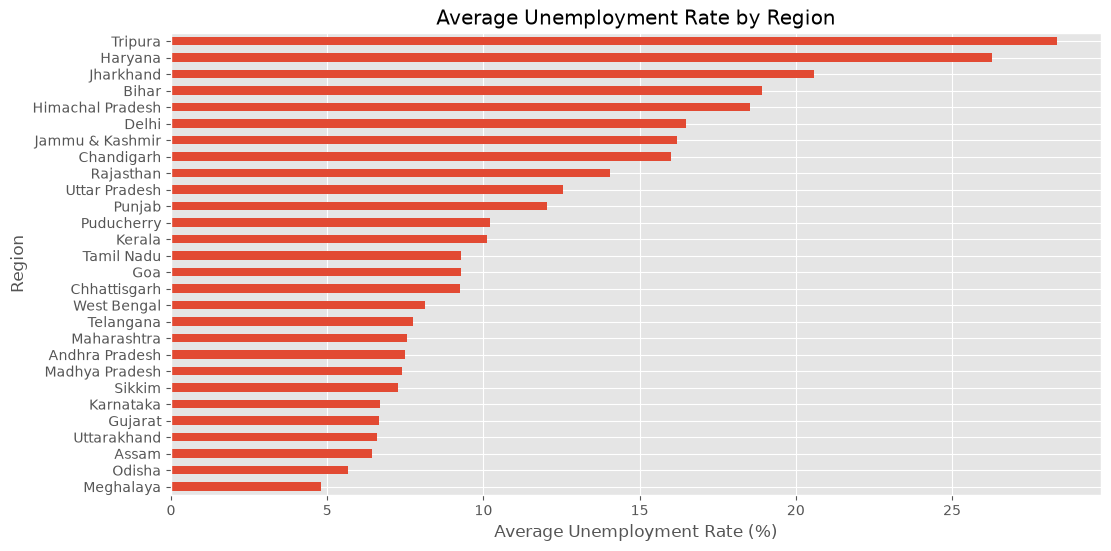

In [6]:
# Visualization 
plt.figure(figsize=(12,6))

region_avg.sort_values().plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.show()

# 6.Month Wise Trend

In [7]:
monthly = df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"].mean()

monthly.index = monthly.index.astype(str)

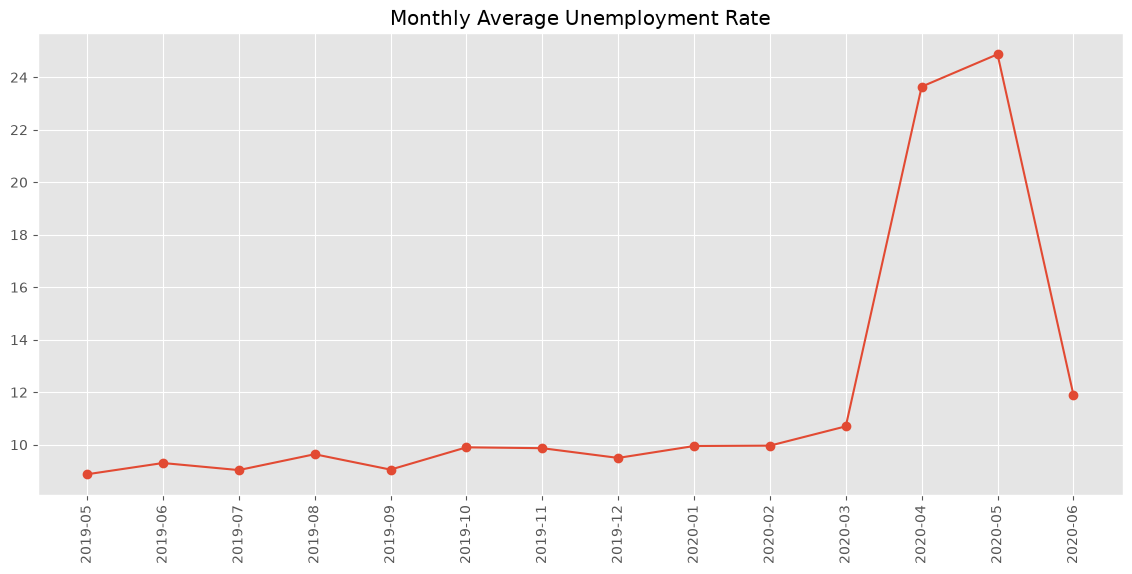

In [8]:
plt.figure(figsize=(14,6))

plt.plot(monthly.index,
         monthly.values,
         marker='o')

plt.xticks(rotation=90)

plt.title("Monthly Average Unemployment Rate")

plt.show()

# 7. Time Series for three major States


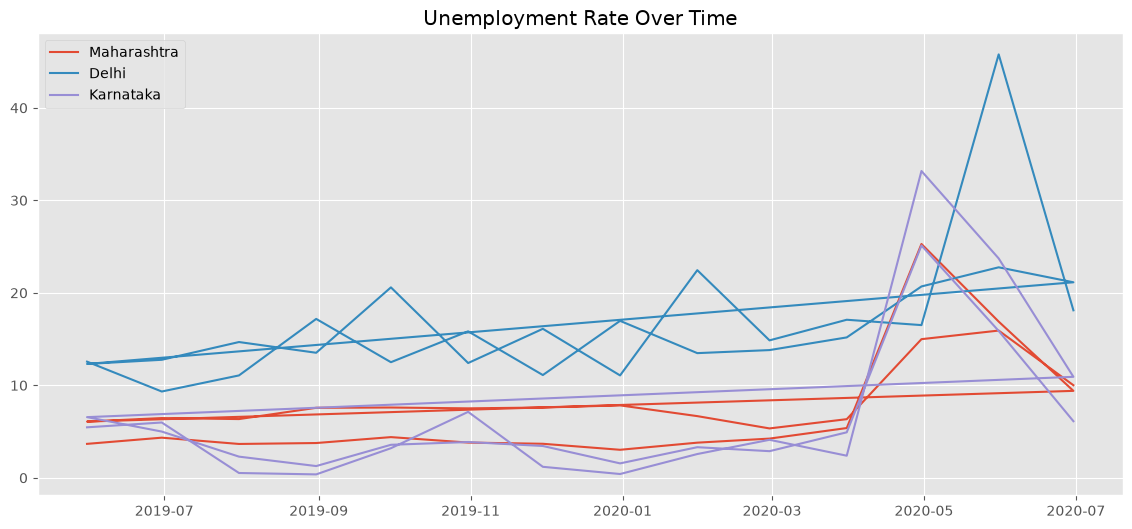

In [11]:
states = ["Maharashtra","Delhi","Karnataka"]

plt.figure(figsize=(14,6))

for state in states:
    data = df[df["Region"]==state]
    plt.plot(
        data["Date"],
        data["Estimated Unemployment Rate (%)"],
        label=state
    )

plt.legend()

plt.title("Unemployment Rate Over Time")

plt.show()

# 8. Top 10 States


In [12]:
top10 = region_avg.sort_values(
    ascending=False
).head(10)

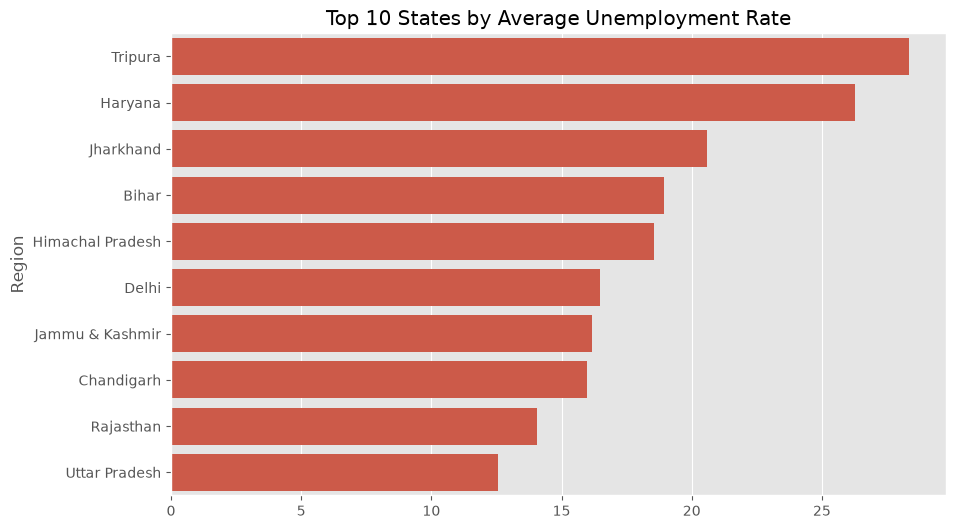

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by Average Unemployment Rate")

plt.show()

# 9. Correlation Heatmap

In [14]:
corr = df[
[
"Estimated Unemployment Rate (%)",
"Estimated Employed",
"Estimated Labour Participation Rate (%)"
]
].corr()

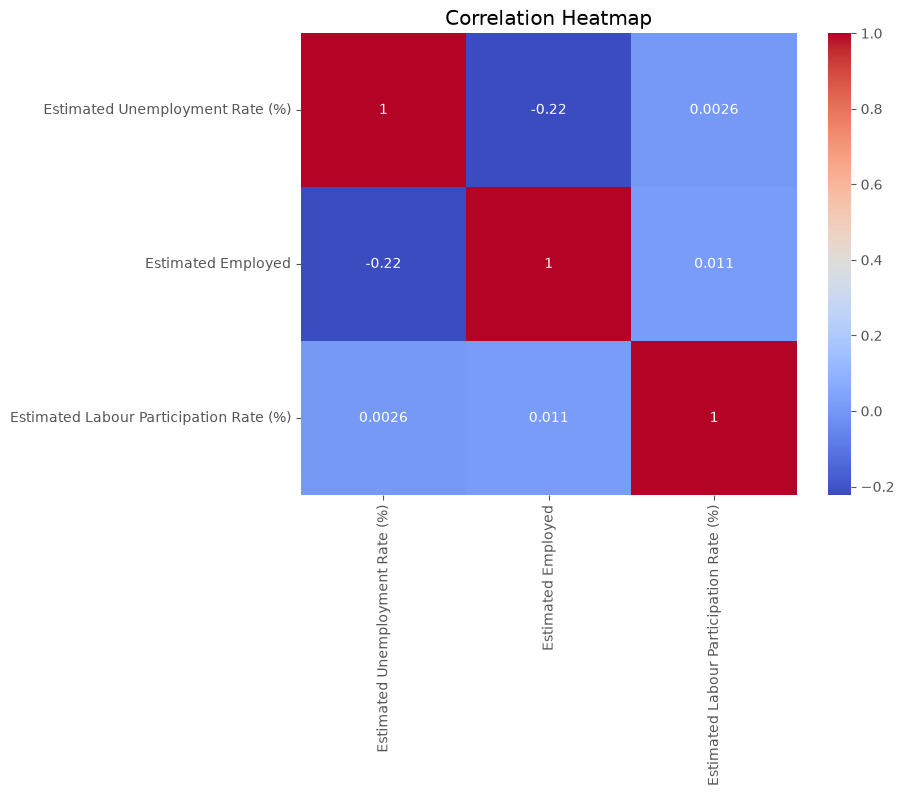

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

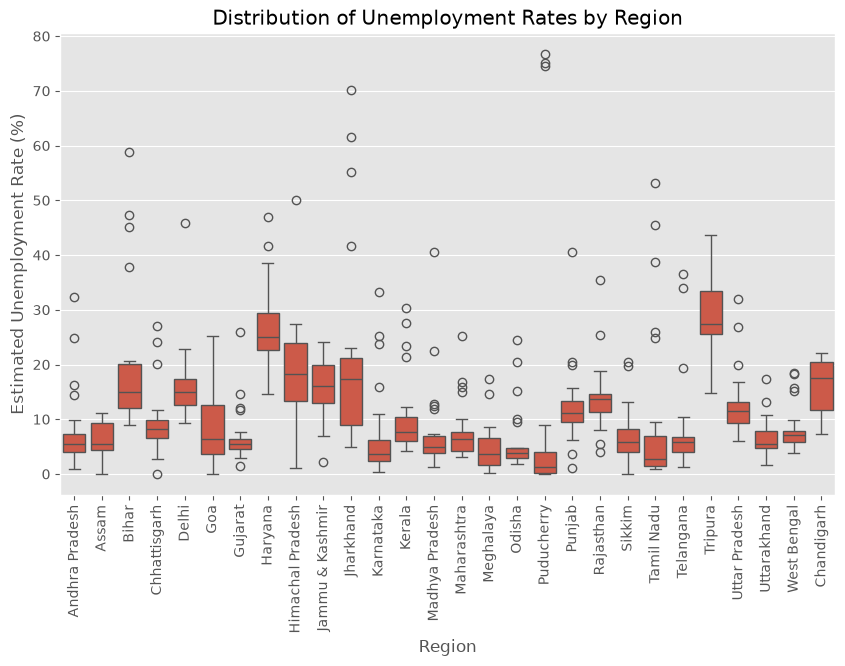

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Region",
    y="Estimated Unemployment Rate (%)"
)

plt.xticks(rotation=90)

plt.title("Distribution of Unemployment Rates by Region")

plt.show()

# 10. Pre-Covid vs Post-Covid

In [17]:
pre = df[df["Date"] < "2020-03-01"]

post = df[df["Date"] >= "2020-03-01"]

In [18]:
print("Pre-COVID")

print(pre["Estimated Unemployment Rate (%)"].mean())

print("Post-COVID")

print(post["Estimated Unemployment Rate (%)"].mean())

Pre-COVID
9.509533582089553
Post-COVID
17.774362745098042


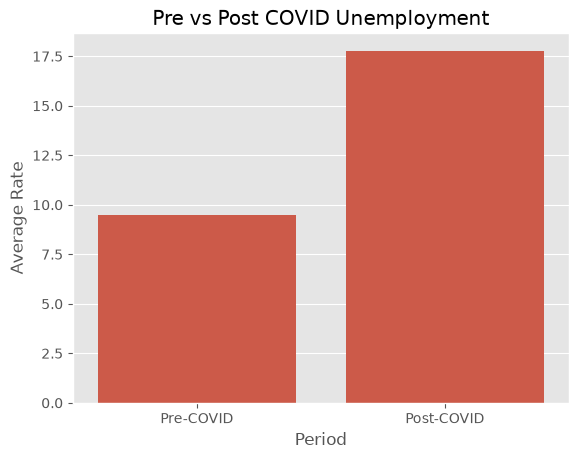

In [19]:
comparison = pd.DataFrame({
    "Period":["Pre-COVID","Post-COVID"],
    "Average Rate":[
        pre["Estimated Unemployment Rate (%)"].mean(),
        post["Estimated Unemployment Rate (%)"].mean()
    ]
})

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Rate"
)

plt.title("Pre vs Post COVID Unemployment")

plt.show()

# ** Conclusion **



The analysis shows significant regional variation in unemployment across India.

Time-series analysis indicates a sharp increase in unemployment during the
COVID-19 pandemic, followed by gradual recovery.

Correlation analysis suggests relationships between unemployment,
employment, and labour participation.

Overall, the COVID-19 pandemic had a substantial negative impact on
employment across multiple Indian states.